
Logistic Regression (SMOTE) Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

Logistic Regression (SMOTE) F1 Score: 0.1061
Logistic Regression (SMOTE) Precision: 0.0563
Logistic Regression (SMOTE) Recall: 0.9184
Logistic Regression (SMOTE) ROC AUC: 0.9459


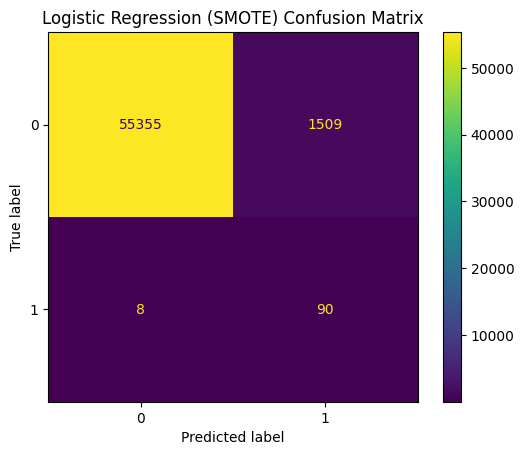


Random Forest (SMOTE) Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Random Forest (SMOTE) F1 Score: 0.8601
Random Forest (SMOTE) Precision: 0.8737
Random Forest (SMOTE) Recall: 0.8469
Random Forest (SMOTE) ROC AUC: 0.9234


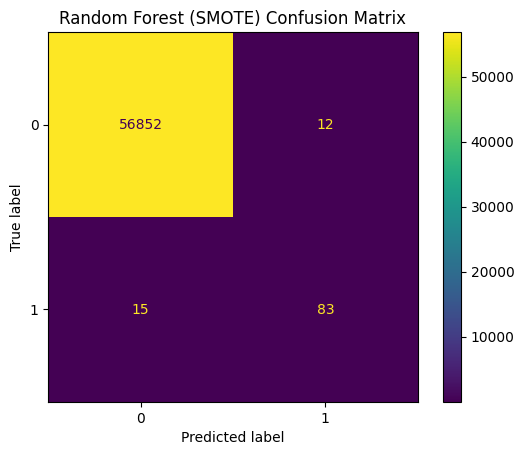


Random Forest (UnderSampling) Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.91      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962

Random Forest (UnderSampling) F1 Score: 0.0870
Random Forest (UnderSampling) Precision: 0.0457
Random Forest (UnderSampling) Recall: 0.9082
Random Forest (UnderSampling) ROC AUC: 0.9377


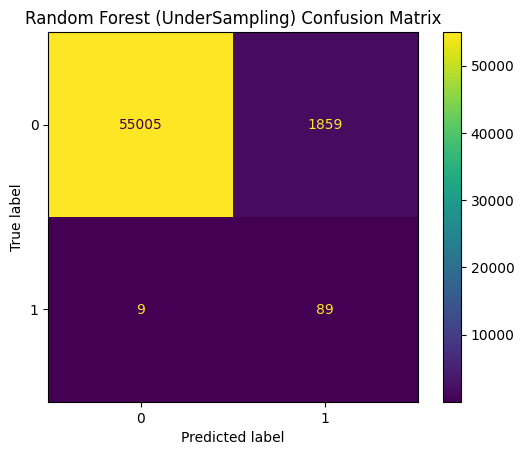

Best model and scaler saved in 'models/' directory.


In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import joblib
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))

scaler = StandardScaler()
df['normAmount'] = scaler.fit_transform(df[['Amount']])
df.drop(['Time', 'Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_smote, y_smote)
log_preds = log_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=20, random_state=42)
rf_model.fit(X_smote, y_smote)
rf_preds = rf_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Classification Report:")
    print(classification_report(y_true, y_pred))
    print(f"{name} F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"{name} Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"{name} Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"{name} ROC AUC: {roc_auc_score(y_true, y_pred):.4f}")
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

evaluate_model("Logistic Regression (SMOTE)", y_test, log_preds)
evaluate_model("Random Forest (SMOTE)", y_test, rf_preds)

rf_rus_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_rus_model.fit(X_rus, y_rus)
rf_rus_preds = rf_rus_model.predict(X_test)
evaluate_model("Random Forest (UnderSampling)", y_test, rf_rus_preds)

os.makedirs("models", exist_ok=True)
joblib.dump(rf_model, "models/fraud_detection_model.pkl")
joblib.dump(scaler, "models/amount_scaler.pkl")
print("Best model and scaler saved in 'models/' directory.")
